In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [52]:
df = pd.read_csv('../titanic.csv', usecols=['Age', 'Fare', 'Survived'])

In [53]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [54]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [55]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [58]:
X_test.head()

,Age,Fare,Age_imputed
709,NaN,15.2458,NaN
439,31.0,10.5000,31.0
840,20.0,7.9250,20.0
720,6.0,33.0000,6.0
39,14.0,11.2417,14.0


In [59]:
# to get all the null values in the Age_imputed column
X_train['Age_imputed'][X_train['Age_imputed'].isnull()]

29    NaN
55    NaN
533   NaN
495   NaN
468   NaN
       ..
330   NaN
214   NaN
466   NaN
121   NaN
270   NaN
Name: Age_imputed, Length: 140, dtype: float64

In [60]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values



C:\Users\gurpr\AppData\Local\Temp\ipykernel_7476\2115887445.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values


In [61]:
X_train

,Age,Fare,Age_imputed
331,45.5,28.5000,45.5
733,23.0,13.0000,23.0
382,32.0,7.9250,32.0
704,26.0,7.8542,26.0
813,6.0,31.2750,6.0
...,...,...,...
106,21.0,7.6500,21.0
270,NaN,31.0000,29.0
860,41.0,14.1083,41.0
435,14.0,120.0000,14.0


C:\Users\gurpr\AppData\Local\Temp\ipykernel_7476\1385575057.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'], label='Original', hist = False)
C:\Users\gurpr\AppData\Local\Temp\ipykernel_7476\1385575057.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_trai

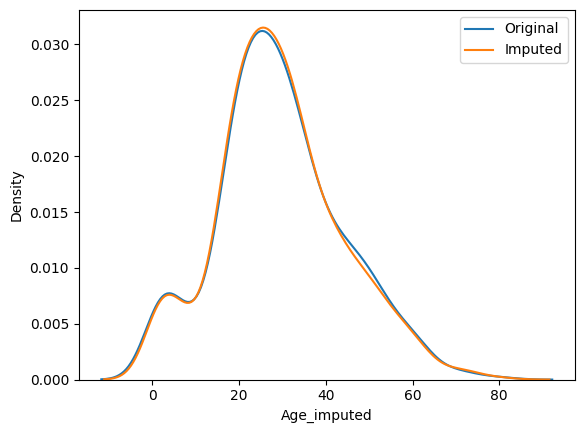

In [62]:
sns.distplot(X_train['Age'], label='Original', hist = False)
sns.distplot(X_train['Age_imputed'], label='Imputed', hist = False)
plt.legend()
plt.show()

In [63]:
print('Original variale variance:', X_train['Age'].var())
print('Imputed variable variance:', X_train['Age_imputed'].var())

Original variale variance: 210.2517072477435
Imputed variable variance: 205.85847159326158


In [64]:
X_train[['Fare', 'Age', 'Age_imputed']].corr()
# correlation has indeed changed but mean and variance are almost the same.

,Fare,Age,Age_imputed
Fare,1.000000,0.088103,0.08324
Age,0.088103,1.000000,1.00000
Age_imputed,0.083240,1.000000,1.00000


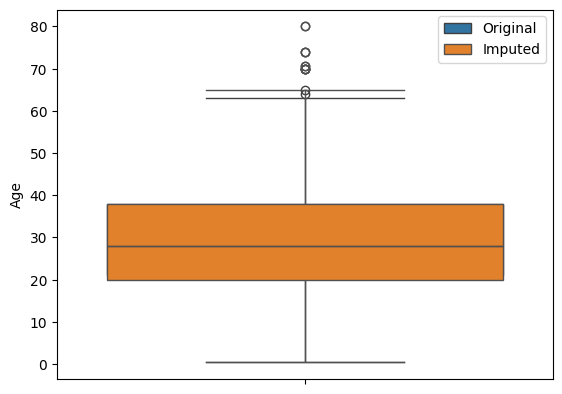

In [65]:
sns.boxplot(X_train['Age'], label='Original')
sns.boxplot(X_train['Age_imputed'], label='Imputed')
plt.legend()

In [66]:
#in production this is important to make sure that the random state is same for all the observations. Otherwise, we will get different random values for each observation and it will be difficult to reproduce the results.

sampled_value = X_train['Age'].dropna().sample(1, random_state = int(observation['Fare']))

NameError: name 'observation' is not defined

In [67]:
#categorical_data
data = pd.read_csv('../house-train.csv', usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])

In [68]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [69]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [70]:
X =data
y = data['SalePrice']
X_test, X_train, y_test, y_train = train_test_split(X, y, test_size=0.2, random_state=42)

In [71]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [73]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
567,NaN,TA,214000,TA,NaN
451,TA,TA,280000,TA,TA
478,Gd,TA,297000,TA,Gd
1344,TA,TA,155835,TA,TA
261,Gd,TA,276000,TA,Gd


In [74]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values

C:\Users\gurpr\AppData\Local\Temp\ipykernel_7476\2139002913.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual

In [75]:
X_train


,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
892,NaN,TA,154500,TA,TA
1105,TA,TA,325000,TA,TA
413,Gd,TA,115000,TA,Gd
522,Gd,TA,159000,TA,Gd
1036,Ex,TA,315500,TA,Ex
...,...,...,...,...,...
479,NaN,TA,89471,TA,TA
1361,Gd,TA,260000,TA,Gd
802,Gd,TA,189000,TA,Gd
651,Gd,Fa,108000,Fa,Gd


In [79]:
temp =pd.concat([
    X_train['GarageQual'].value_counts()/len(X_train['GarageQual'].dropna()),
    X_train['GarageQual_imputed'].value_counts()/len(X_train['GarageQual_imputed']),
], 
axis=1)

temp.columns = ['Original', 'Imputed']
temp

,Original,Imputed
TA,0.949091,0.948630
Fa,0.043636,0.044521
Po,0.003636,0.003425
Gd,0.003636,0.003425


In [80]:
temp =pd.concat([
    X_train['FireplaceQu'].value_counts()/len(X_train['FireplaceQu'].dropna()),
    X_train['FireplaceQu_imputed'].value_counts()/len(X_train['FireplaceQu_imputed']),
], 
axis=1)

temp.columns = ['Original', 'Imputed']
temp

,Original,Imputed
Gd,0.503356,0.496575
TA,0.409396,0.414384
Fa,0.040268,0.041096
Po,0.026846,0.027397
Ex,0.020134,0.020548


C:\Users\gurpr\AppData\Local\Temp\ipykernel_7476\1194715002.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'], label=category, hist=False)
C:\Users\gurpr\AppData\Local\Temp\ipykernel_7476\1194715002.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457a

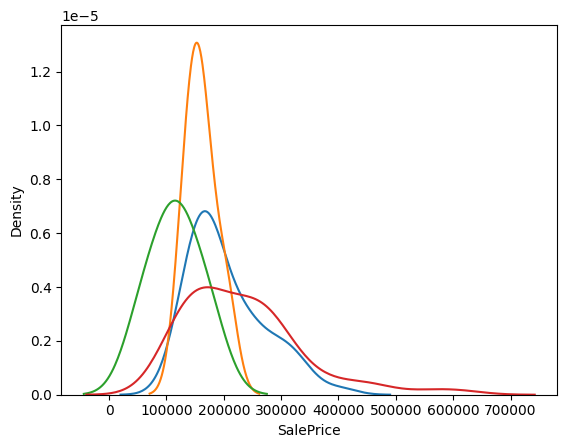

In [81]:
for category in X_train['GarageQual'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'], label=category, hist=False)

C:\Users\gurpr\AppData\Local\Temp\ipykernel_7476\3738424926.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'], label=category, hist=False)
C:\Users\gurpr\AppData\Local\Temp\ipykernel_7476\3738424926.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed

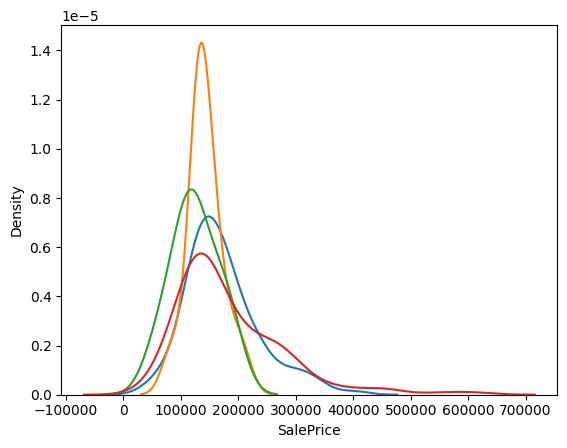

In [82]:
for category in X_train['GarageQual'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'], label=category, hist=False)